### Building Simple Graph:

Số lượng connected components: 1
Tổng số nút: 20
Tổng số cạnh: 30


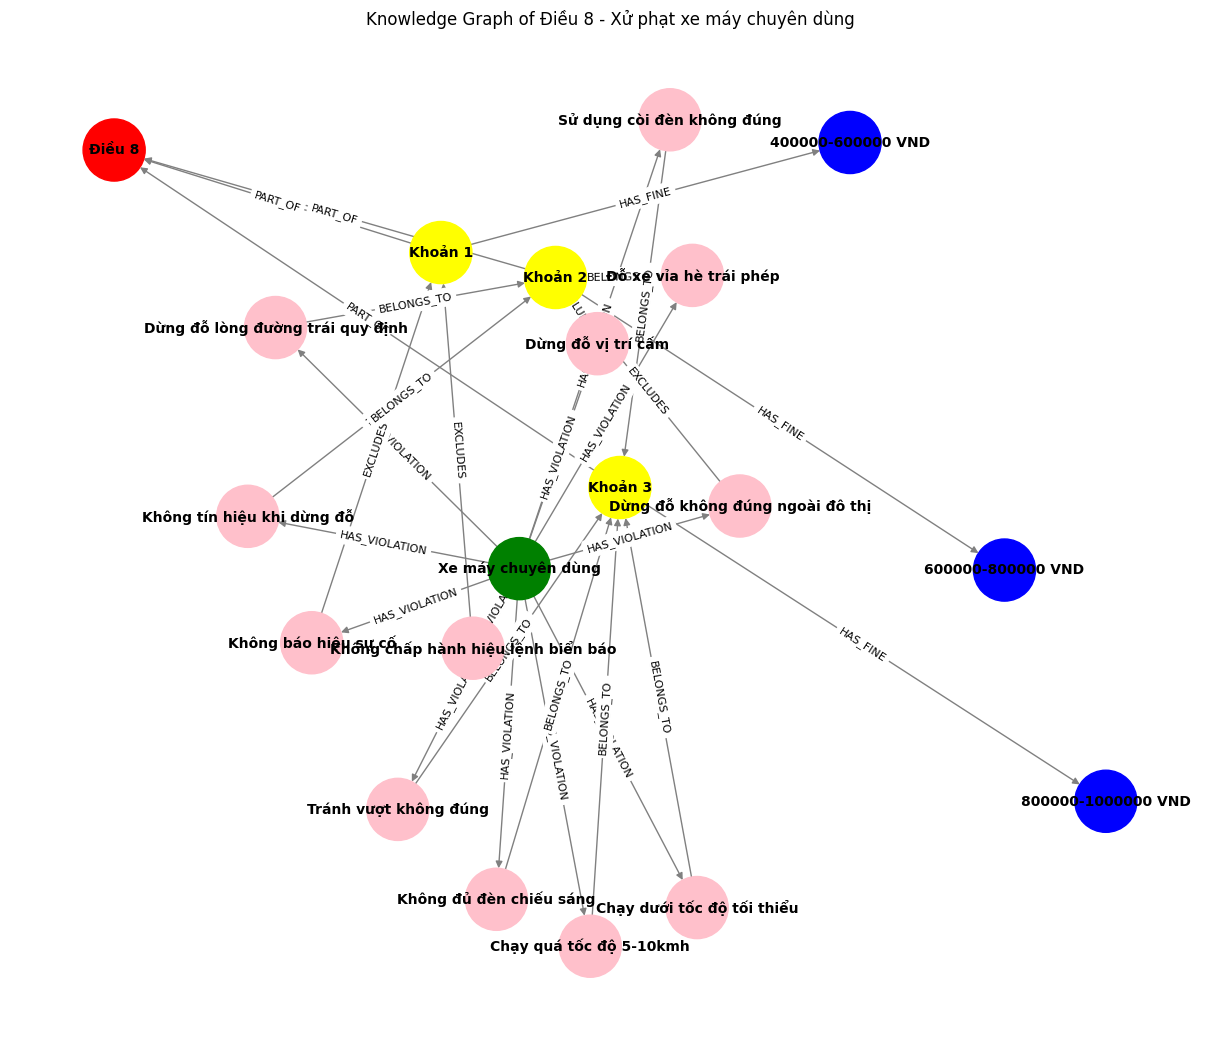

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Tạo graph có hướng
G = nx.DiGraph()

# Thêm nút Regulation
G.add_node('r', label='Regulation', name='Điều 8')

# Thêm nút Vehicle
G.add_node('veh', label='Vehicle', type='Xe máy chuyên dùng')

# Thêm các nút Clause
G.add_node('c1', label='Clause', name='Khoản 1')
G.add_node('c2', label='Clause', name='Khoản 2')
G.add_node('c3', label='Clause', name='Khoản 3')

# Thêm các nút Fine
G.add_node('f1', label='Fine', amount='400000-600000 VND')
G.add_node('f2', label='Fine', amount='600000-800000 VND')
G.add_node('f3', label='Fine', amount='800000-1000000 VND')

# Thêm các nút Violation
G.add_node('v1a', label='Violation', name='Không chấp hành hiệu lệnh biển báo')
G.add_node('v1b', label='Violation', name='Không báo hiệu sự cố')
G.add_node('v2a', label='Violation', name='Dừng đỗ không đúng ngoài đô thị')
G.add_node('v2b', label='Violation', name='Dừng đỗ vị trí cấm')
G.add_node('v2c', label='Violation', name='Dừng đỗ lòng đường trái quy định')
G.add_node('v2d', label='Violation', name='Không tín hiệu khi dừng đỗ')
G.add_node('v2e', label='Violation', name='Đỗ xe vỉa hè trái phép')
G.add_node('v3a', label='Violation', name='Chạy quá tốc độ 5-10kmh')
G.add_node('v3b', label='Violation', name='Sử dụng còi đèn không đúng')
G.add_node('v3c', label='Violation', name='Không đủ đèn chiếu sáng')
G.add_node('v3d', label='Violation', name='Tránh vượt không đúng')
G.add_node('v3e', label='Violation', name='Chạy dưới tốc độ tối thiểu')

# Thêm edges PART_OF (Clause -> Regulation)
G.add_edge('c1', 'r', type='PART_OF')
G.add_edge('c2', 'r', type='PART_OF')
G.add_edge('c3', 'r', type='PART_OF')

# Thêm edges HAS_FINE (Clause -> Fine)
G.add_edge('c1', 'f1', type='HAS_FINE')
G.add_edge('c2', 'f2', type='HAS_FINE')
G.add_edge('c3', 'f3', type='HAS_FINE')

# Thêm edges HAS_VIOLATION (Vehicle -> Violation)
G.add_edge('veh', 'v1a', type='HAS_VIOLATION')
G.add_edge('veh', 'v1b', type='HAS_VIOLATION')
G.add_edge('veh', 'v2a', type='HAS_VIOLATION')
G.add_edge('veh', 'v2b', type='HAS_VIOLATION')
G.add_edge('veh', 'v2c', type='HAS_VIOLATION')
G.add_edge('veh', 'v2d', type='HAS_VIOLATION')
G.add_edge('veh', 'v2e', type='HAS_VIOLATION')
G.add_edge('veh', 'v3a', type='HAS_VIOLATION')
G.add_edge('veh', 'v3b', type='HAS_VIOLATION')
G.add_edge('veh', 'v3c', type='HAS_VIOLATION')
G.add_edge('veh', 'v3d', type='HAS_VIOLATION')
G.add_edge('veh', 'v3e', type='HAS_VIOLATION')

# Thêm edges BELONGS_TO (Violation -> Clause)
G.add_edge('v1a', 'c1', type='BELONGS_TO')
G.add_edge('v1b', 'c1', type='BELONGS_TO')
G.add_edge('v2a', 'c2', type='BELONGS_TO')
G.add_edge('v2b', 'c2', type='BELONGS_TO')
G.add_edge('v2c', 'c2', type='BELONGS_TO')
G.add_edge('v2d', 'c2', type='BELONGS_TO')
G.add_edge('v2e', 'c2', type='BELONGS_TO')
G.add_edge('v3a', 'c3', type='BELONGS_TO')
G.add_edge('v3b', 'c3', type='BELONGS_TO')
G.add_edge('v3c', 'c3', type='BELONGS_TO')
G.add_edge('v3d', 'c3', type='BELONGS_TO')
G.add_edge('v3e', 'c3', type='BELONGS_TO')

# Thêm edges EXCLUDES (Violation -> Clause)
G.add_edge('v1a', 'c1', type='EXCLUDES')
G.add_edge('v1b', 'c1', type='EXCLUDES')
G.add_edge('v2a', 'c2', type='EXCLUDES')
G.add_edge('v2b', 'c2', type='EXCLUDES')

# Kiểm tra số lượng weakly connected components
num_components = nx.number_weakly_connected_components(G)
print(f'Số lượng connected components: {num_components}')
print(f'Tổng số nút: {G.number_of_nodes()}')
print(f'Tổng số cạnh: {G.number_of_edges()}')

# Trực quan hóa graph
plt.figure(figsize=(12, 10))

# Layout dạng spring để các nút phân bố hợp lý
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Gán màu sắc theo loại nút
node_colors = []
for node in G.nodes(data=True):
    label = node[1]['label']
    if label == 'Vehicle':
        node_colors.append('green')
    elif label == 'Regulation':
        node_colors.append('red')
    elif label == 'Clause':
        node_colors.append('yellow')
    elif label == 'Fine':
        node_colors.append('blue')
    elif label == 'Violation':
        node_colors.append('pink')

# Hàm lấy nhãn hiển thị
def get_node_label(node_data):
    if 'name' in node_data:
        return node_data['name']
    elif 'type' in node_data:
        return node_data['type']
    elif 'amount' in node_data:
        return node_data['amount']
    else:
        return node_data.get('label', 'Unknown')

# Tạo dict labels
labels = {node: get_node_label(node_data) for node, node_data in G.nodes(data=True)}

# Vẽ nút và cạnh
nx.draw(G, pos, with_labels=True, labels=labels,
        node_color=node_colors, node_size=2000, font_size=10, font_weight='bold', edge_color='gray')

# Vẽ nhãn cho cạnh
edge_labels = {(u, v): d['type'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=8)

# Hiển thị đồ thị
plt.title("Knowledge Graph of Điều 8 - Xử phạt xe máy chuyên dùng")
plt.show()